**Data-Driven Crop Recommendation**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/agricultural_with_seasons.csv')

In [3]:
df

,Product,Season,Region,Soil_Type,Irrigation_Method,Avg_Yield_ton_per_hectare,Market_Price_Rs_per_kg,Water_Requirement_mm,Growth_Duration_days,Fertilizer_Usage_kg_per_hectare,Pesticide_Usage_liters_per_hectare,Seed_Rate_kg_per_hectare,Labor_Days_required,Avg_Rainfall_mm,Temperature_C,PH_Soil,Sowing_Month,Harvest_Month,Export_Potential,Subsidy_Eligible
0,Banana,Rabi,West,Peaty,Drip,3.79,61.57,819.6,81,163.7,2.36,15.6,10.0,1044.9,16.1,7.92,October,April,Low,Yes
1,Mango,All Season,North-East,Sandy,Drip,5.09,53.4,1234.3,130,75.2,3.34,44.0,59.0,730.9,31.3,6.64,August,April,Moderate,No
2,Rice,All Season,East,Peaty,Sprinkler,7.61,35.56,1585.5,144,245.5,3.50,36.4,44.0,1169.8,21.1,7.42,December,February,Moderate,Yes
3,Wheat,Kharif,North-East,Silty,Surface,8.50,5.22,1002.5,98,154.8,0.67,5.2,59.0,NaN,17.8,6.82,October,March,High,No
4,Sugarcane,All Season,North-East,Peaty,Sprinkler,8.66,94.98,775.7,147,150.6,2.52,12.1,55.0,1236.7,37.0,6.54,December,May,Moderate,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Sugarcane,Rabi,Central,Clay,Manual,6.00,89.74,1599.0,115,180.6,4.53,8.4,56.0,1080.2,20.4,6.99,December,March,High,Yes
196,Mustard,All Season,North-East,Clay,Surface,2.09,69.71,669.5,139,237.8,0.57,@@@NOISE###,50.0,896.0,25.3,6.77,August,May,High,Yes
197,Apple,Rabi,North-East,Saline,NaN,3.82,64.61,265.8,177,245.3,3.49,48.6,17.0,902.1,22.0,6.01,June,May,High,No
198,Banana,All Season,West,Silty,Manual,2.74,34.66,1318.3,144,242.3,4.96,7.5,12.0,680.5,23.4,6.55,December,February,High,No


In [4]:
df.columns

Index(['Product', 'Season', 'Region', 'Soil_Type', 'Irrigation_Method',
       'Avg_Yield_ton_per_hectare', 'Market_Price_Rs_per_kg',
       'Water_Requirement_mm', 'Growth_Duration_days',
       'Fertilizer_Usage_kg_per_hectare', 'Pesticide_Usage_liters_per_hectare',
       'Seed_Rate_kg_per_hectare', 'Labor_Days_required', 'Avg_Rainfall_mm',
       'Temperature_C', 'PH_Soil', 'Sowing_Month', 'Harvest_Month',
       'Export_Potential', 'Subsidy_Eligible'],
      dtype='object')

**FEATURE DESCRIPTION :-**

*   **Product** - The name of the agricultural crop
*   **Season** - The main growing season for the crop

*   **Region** - Geographic region of cultivation
*   **Soil_Type** - Type of soil preferred for the crop

*   **Irrigation_Method** - The technique used to irrigate the crop
*   **Avg_Yield_ton_per_hectare** - Average crop yield per hectare

*   **Market_Price_Rs_per_kg** - Average market selling price in Indian Rupees per kilogram
*   **Water_Requirement_mm** - Total water needed during the crop cycle (mm)


*   **Growth_Duration_days** - Number of days from sowing to harvest
*   **Fertilizer_Usage_kg_per_hectare** - Average fertilizer applied per hectare (kg)

*   **Pesticide_Usage_liters_per_hectare** - Pesticide usage per hectare (L)
*   **Seed_Rate_kg_per_hectare** - Quantity of seeds sown per hectare (kg)

*   **Labor_Days_required** - Number of labor days required throughout the crop cycle
*   **Avg_Rainfall_mm** - Average rainfall received during cultivation, in millimeters

*   **Temperature_C** - Optimal average temperature required for growth (in degree celsius)
*   **PH_Soil** - Soil pH value, indicating acidity/alkalinity suitable for the crop

*   **Sowing_Month** - Month when the crop is sown
*   **Harvest_Month** - Month when the crop is harvested

*   **Export_Potential** - Level of international market potential (Low, Moderate, High)
*   **Subsidy_Eligible** - indicates whether the crop qualifies for government subsidy (Yes/No)
























---


**PREPROCESSING OF AGRICULTURE_WITH_SEASONS DATASET**


---



Visualizing and Dealing with Noise Values :-

In [5]:
df.isnull().sum()

,0
Product,0
Season,0
Region,0
Soil_Type,0
Irrigation_Method,38
Avg_Yield_ton_per_hectare,0
Market_Price_Rs_per_kg,0
Water_Requirement_mm,0
Growth_Duration_days,0
Fertilizer_Usage_kg_per_hectare,0


**(Dealing with placeholders in different columns)**

1. Irrigation_Method

In [6]:
print("Null values in Irrigation_Method column: ", df['Irrigation_Method'].isnull().sum())
df['Irrigation_Method'].unique()        #dentify typos, inconsistent labels or any placeholder values like 'NA', 'None', or '--' that may need to be cleaned
print('\n')
df['Irrigation_Method'] = df['Irrigation_Method'].replace('--', np.nan)
print("Null values after replacement: ", df['Irrigation_Method'].isnull().sum())      #'--' now is being treated as null value

Null values in Irrigation_Method column:  38


Null values after replacement:  39


2. Labor_Days_required

In [7]:
print("Null values in Labor_Days_required column: ", df['Labor_Days_required'].isnull().sum())
df['Labor_Days_required'].unique()      #No placeholder present

Null values in Labor_Days_required column:  1


array([10., 59., 44., 55., 33., 49., 12., 25., 45., 38., 14., 43., 51.,
       18., 57., 19., 28., 11., 31., 26., 22., 50., 48., 23., 58., 20.,
       32., 15., 36., 54., 42., 24., 30., 46., 53., 52., 21., 37., 16.,
       39., 27., 29., 34., 13., 60., 40., 35., 41., 56., nan, 17., 47.])

3. Avg_Rainfall_mm

In [8]:
print("Null values in Avg_Rainfall_mm column: ", df['Avg_Rainfall_mm'].isnull().sum())
df['Avg_Rainfall_mm'].unique()              #No placeholder present

Null values in Avg_Rainfall_mm column:  1


array([1044.9,  730.9, 1169.8,    nan, 1236.7, 1441. ,  604.9,  537.5,
        951.9,  433.9,  691.7, 1211.8, 1358.1,  451.3,  948.8,  531.5,
        921.7, 1343.3, 1350.3, 1250.9,  867.5, 1304. ,  623.5,  343.2,
        964. , 1008. ,  515.4, 1212.4,  694. , 1464.2, 1411.9,  536.5,
       1458.8, 1104.1,  496.1,  996.6, 1154.4,  967.3,  705.4,  913. ,
        903.1,  444.6,  567.4,  951.5, 1066.4, 1197.6,  734.6, 1162.4,
        776.1,  660.6,  973. , 1031.1,  625.6,  923. ,  558.2,  742.1,
        318.6,  838.1, 1196.9,  941.7, 1388. ,  977.3, 1155.3, 1330.6,
       1359.2, 1455.8, 1375. ,  707.9,  436.2,  444.9, 1302.8, 1172.9,
        554.3, 1200.8,  576.7,  661.7,  541.8, 1434.9, 1486. , 1394.8,
        466.5,  721.6,  814.8,  408.7, 1131.4, 1130.1,  869.6,  558.9,
       1367.3,  519.9,  748.9, 1035.8,  835.8,  586.2,  682.7,  643.4,
        851.2, 1287. ,  469. ,  600.2, 1278.6, 1243.7,  780.1,  830.3,
        512.7, 1148.9,  732.3, 1224.4,  684. ,  352.8,  337.7, 1449.7,
      

In [9]:
# As there are no placeholders but still there is a null value, so there is only one null value to be dealt with

invalid_indices=[]
for i, val in df['Avg_Rainfall_mm'].items():
  try:
    float(val)
  except ValueError:
    invalid_indices.append(i)
print(invalid_indices)

[]


4. Temperature_C

In [10]:
print("Null values in Temperature_C column: ", df['Temperature_C'].isnull().sum())
df['Temperature_C'].unique()

Null values in Temperature_C column:  1


array([16.1, 31.3, 21.1, 17.8, 37. , 17.4, 38.1, 26.8, 33.3, 23.8, 34. ,
       34.1, 25.5, 30.9, 15.5, 33.6, 33.2, 17.6, 34.6, 15.3, 21.7, 39.5,
       31.6, 30.5, 21.6, 26.3, 23.5, 21.2, 38.6, 30.2, 20.2, 21.5, 37.5,
       19.7, 39.7, 21.9, 27. , 25.8, 29.9, 35.5, 28.7, 32.9, 39.1, 28.4,
       28. , 23.7, 35.9, 17.9, 31.8, 37.3, 22.8, 31.1, 35.2, 15.8, 36.5,
       20.5, 19.5, 15.7, 36.2, 35. , 16.7, 38.4, 25.2, 16.9, 19.2, 32.5,
       18.8, 16. , 34.3, 20.1, 25.7, 20.7, 38.5, 27.7, 31.4, 29.8, 26.4,
       27.2, 34.4, 37.7, 36.1, 32.7, 35.1, 17.5, 34.8, 38.3, 19.6, 23. ,
       17. , 30.7, 19.9, 23.1, 24.9, 33.5, 23.4,  nan, 15.9, 18.4, 23.3,
       37.9, 28.6, 22.7, 18.3, 15.2, 38.9, 30. , 23.9, 32.1, 36.9, 16.4,
       19.4, 32.4, 34.5, 31. , 37.1, 26.2, 38. , 16.8, 34.9, 26. , 35.3,
       29. , 21.8, 32.2, 33.4, 20.4, 27.5, 29.6, 36. , 36.8, 33.8, 22.1,
       29.3, 18. , 23.2, 19.1, 25. , 39.8, 26.9, 25.3, 22. , 28.5])

In [11]:
#As there are no placeholders but still there is a null value, so there is only one null value to be dealt with

invalid_indices=[]
for i, val in df['Temperature_C'].items():
  try:
    float(val)
  except ValueError:
    invalid_indices.append(i)
print(invalid_indices)

[]


5. Sowing_Month

In [12]:
print("Null values in Sowing_Month column: ", df['Sowing_Month'].isnull().sum())  #no placeholders, only one null value to be dealt with
df['Sowing_Month'].unique()

Null values in Sowing_Month column:  1


array(['October', 'August', 'December', 'June', 'July', 'November', nan],
      dtype=object)

6. Harvest_Month

In [13]:
print("Null values in Harvest_Month column: ", df['Harvest_Month'].isnull().sum())  #no placeholders, only one null value to be dealt with
df['Harvest_Month'].unique()

Null values in Harvest_Month column:  1


array(['April', 'February', 'March', 'May', 'January', nan], dtype=object)

7. Export_Potential

In [14]:
print("Null values in Export_Potential column: ", df['Export_Potential'].isnull().sum())
df['Export_Potential'].unique()        #One placeholder and one null value to be dealt with

Null values in Export_Potential column:  1


array(['Low', 'Moderate', 'High', nan, '@@@NOISE###'], dtype=object)

In [15]:
df['Export_Potential'] = df['Export_Potential'].replace('@@@NOISE###', np.nan)
print("Null values after replacement: ", df['Export_Potential'].isnull().sum())

Null values after replacement:  2


8. Subsidy_Eligible

In [16]:
print("Null values in Subsidy_Eligible column: ", df['Subsidy_Eligible'].isnull().sum())
df['Subsidy_Eligible'].unique()                #no placeholders, only one null value to be dealt with

Null values in Subsidy_Eligible column:  1


array(['Yes', 'No', nan], dtype=object)

9. Product

In [17]:
print("Null values in Product column: ", df['Product'].isnull().sum())
df['Product'].unique()                  #One placeholder to be dealt with

Null values in Product column:  0


array(['Banana', 'Mango', 'Rice', 'Wheat', 'Sugarcane', 'Tomato', 'Tea',
       'Groundnut', 'Apple', 'Coffee', 'Mustard', 'Potato', 'Barley',
       'Sunflower', 'Cotton', 'Maize', 'Grapes', 'Onion', 'Chili',
       'Soybean', '@@@NOISE###'], dtype=object)

In [18]:
df['Product'] = df['Product'].replace('@@@NOISE###', np.nan)
print("Null values after replacement: ", df['Product'].isnull().sum())    #That one placehoder got converted into null value

Null values after replacement:  1


10. Season

In [19]:
print("Null values in Season column: ", df['Season'].isnull().sum())
df['Season'].unique()     #One placeholder to be dealt with

Null values in Season column:  0


array(['Rabi', 'All Season', 'Kharif', 'Zaid', '@@@NOISE###'],
      dtype=object)

In [20]:
df['Season'] = df['Season'].replace('@@@NOISE###', np.nan)
print("Null values after replacement: ", df['Product'].isnull().sum())    #That one placehoder got converted into null value

Null values after replacement:  1


11. Region

In [21]:
print("Null values in Region column: ", df['Region'].isnull().sum())
df['Region'].unique()              #One placeholder to be dealt with

Null values in Region column:  0


array(['West', 'North-East', 'East', 'North', 'South', 'Central',
       '@@@NOISE###'], dtype=object)

In [22]:
df['Region'] = df['Region'].replace('@@@NOISE###', np.nan)
print("Null values after replacement: ", df['Region'].isnull().sum())
     #That one placehoder got converted to null value

Null values after replacement:  1


12. Soil_Type

In [23]:
print("Null values in Soil_Type column: ", df['Soil_Type'].isnull().sum())
df['Soil_Type'].unique()              #One placeholder to be dealt with

Null values in Soil_Type column:  0


array(['Peaty', 'Sandy', 'Silty', 'Clay', 'Loamy', 'Saline',
       '@@@NOISE###'], dtype=object)

In [24]:
df['Soil_Type'] = df['Soil_Type'].replace('@@@NOISE###', np.nan)
print("Null values after replacement: ", df['Soil_Type'].isnull().sum())   #That one placehoder got converted into null value

Null values after replacement:  1


13. Avg_Yield_ton_per_hectare

In [25]:
print("Null values in Avg_Yield_ton_per_hectare column: ", df['Avg_Yield_ton_per_hectare'].isnull().sum())
df['Avg_Yield_ton_per_hectare'].unique()

Null values in Avg_Yield_ton_per_hectare column:  0


array([3.79, 5.09, 7.61, 8.5 , 8.66, 2.63, 9.08, 6.35, 6.68, 4.  , 2.42,
       3.97, 6.56, 7.53, 3.99, 6.39, 2.66, 9.15, 3.05, 8.73, 1.17, 1.  ,
       3.58, 8.09, 4.41, 9.16, 7.17, 4.66, 9.38, 2.93, 8.94, 6.76, 5.95,
       1.05, 4.12, 5.46, 6.43, 9.69, 1.75, 1.8 , 6.45, 4.55, 2.12, 7.12,
       3.86, 6.11, 9.59, 3.91, 2.55, 6.85, 9.92, 6.57, 4.4 , 3.75, 4.11,
       7.26, 4.85, 6.97, 4.24, 2.67, 5.53, 2.23, 8.38, 2.94, 4.68, 4.46,
       8.27, 7.72, 3.55, 7.14, 8.06, 2.32, 5.5 , 9.93, 1.6 , 2.65, 2.17,
       7.24, 1.61, 5.7 , 1.25, 8.64, 1.4 , 5.18, 5.81, 4.69, 2.15, 1.16,
       4.59, 4.88, 6.3 , 8.55, 5.22, 1.04, 5.08, 4.94, 4.42, 4.62, 5.14,
       9.85, 8.97, 2.61, 9.05, 5.34, 1.65, 6.1 , 2.71, 5.44, 5.05, 8.81,
       3.85, 5.33, 7.57, 5.71, 3.72, 5.23, 9.27, 9.55, 6.29, 8.86, 5.76,
       8.79, 6.31, 8.92, 8.53, 1.24, 4.6 , 6.83, 2.14, 2.07, 4.18, 3.36,
       6.93, 1.36, 9.71, 8.89, 9.36, 5.59, 1.89, 9.33, 3.25, 9.48, 6.59,
       9.97, 6.48, 9.1 , 5.01, 7.8 , 1.63, 9.81, 2.

In [26]:
invalid_indices=[]
for i, val in df['Avg_Yield_ton_per_hectare'].items():
  try:
    float(val)
  except ValueError:
    invalid_indices.append(i)
print(invalid_indices)                 #No placeholder or null value in column

[]


14. Market_Price_Rs_per_kg

In [27]:
print("Null values in Market_Price_Rs_per_kg column: ", df['Market_Price_Rs_per_kg'].isnull().sum())
df['Market_Price_Rs_per_kg'].unique()

Null values in Market_Price_Rs_per_kg column:  0


array(['61.57', '53.4', '35.56', '5.22', '94.98', '28.49', '88.67',
       '17.63', '52.07', '11.98', '30.34', '64.67', '57.87', '12.49',
       '50.32', '57.45', '71.24', '47.26', '39.96', '17.84', '7.61',
       '79.7', '30.49', '47.5', '59.47', '28.2', '29.5', '17.59', '5.21',
       '78.42', '30.08', '72.52', '50.65', '92.85', '68.6', '64.03',
       '50.82', '10.55', '10.25', '20.54', '26.74', '32.02', '6.36',
       '44.93', '8.6', '65.09', '88.51', '29.25', '25.14', '44.63',
       '93.28', '75.76', '79.08', '6.89', '47.53', '18.54', '46.37',
       '58.66', '50.73', '23.47', '84.71', '41.77', '54.87', '5.74',
       '30.27', '78.14', '21.72', '7.34', '93.24', '52.87', '72.41',
       '12.94', '49.75', '83.24', '81.81', '88.83', '37.91', '13.42',
       '25.21', '31.03', '15.44', '15.14', '83.67', '29.2', '17.51',
       '79.47', '81.66', '37.78', '91.81', '55.33', '17.31', '62.55',
       '17.46', '65.1', '56.82', '54.77', '52.65', '97.04', '9.11',
       '68.31', '7.77', '62.9

In [28]:
invalid_indices=[]
for i, val in df['Market_Price_Rs_per_kg'].items():
  try:
    float(val)
  except ValueError:
    invalid_indices.append(i)
print("Invalid values at index : ")
print(invalid_indices)
print("Invalid values: ")
print(df.loc[invalid_indices, 'Market_Price_Rs_per_kg'])        #Found that a placeholder '--' is present at index 181

Invalid values at index : 
[181]
Invalid values: 
181    --
Name: Market_Price_Rs_per_kg, dtype: object


In [29]:
df['Market_Price_Rs_per_kg'] = df['Market_Price_Rs_per_kg'].replace('--', np.nan)
print("Null values after replacement: ", df['Market_Price_Rs_per_kg'].isnull().sum())    #That one placehoder got converted into null value

Null values after replacement:  1


15. Water_Requirement_mm

In [30]:
print("Null values in Water_Requirement_mm column: ", df['Water_Requirement_mm'].isnull().sum())
df['Water_Requirement_mm'].unique()

Null values in Water_Requirement_mm column:  0


array([ 819.6, 1234.3, 1585.5, 1002.5,  775.7,  517.5, 1081.5,  940.9,
       1545.5, 1048.9,  886.6,  405.9,  583.6,  941.3, 1448.7, 1379.4,
        458.9, 1491.7,  222.1,  732.7, 1209.7,  333.8, 1820. ,  849.4,
       1325.5,  989.6,  495.1,  782.9, 1244.6, 1804.8,  902.9, 1346.6,
       1474.2, 1582.2, 1198.2,  890.2,  736.3,  704.8, 1382.3,  613.2,
       1988.1, 1935.4, 1234.1, 1379.3,  337.8, 1224.7,  519.2,  576.4,
        700.4,  767.8,  883.1, 1947.6, 1007.3, 1459.8,  719.4,  325.3,
       1189.4,  483.3, 1278.4, 1327.8, 1572.6,  725.4, 1916.4,  296. ,
        454.7,  278.9,  641.1, 1249. , 1408. ,  861.5,  747.9, 1890.5,
       1025.6,  824.8,  462.9, 1242.6, 1691.8,  706. ,  871.1, 1477.9,
        606.6, 1557. , 1056. , 1946.2, 1176.4,  291. ,  966. , 1542.3,
       1078.4,  677.1, 1240.8, 1588. ,  927. , 1892.1,  846.9,  988.7,
        976.7,  533.2,  862.1,  668.6, 1889.4, 1550.1, 1901.7,  724.1,
       1669.1, 1514.7, 1165.9, 1904.1, 1650.5,  656.3, 1067.3,  901.3,
      

In [31]:
invalid_indices=[]
for i, val in df['Water_Requirement_mm'].items():
  try:
    float(val)
  except ValueError:
    invalid_indices.append(i)
print("Invalid values at index : ")
print(invalid_indices)
print("Invalid values: ")
print(df.loc[invalid_indices, 'Water_Requirement_mm'])       #No placeholder or null value in column

Invalid values at index : 
[]
Invalid values: 
Series([], Name: Water_Requirement_mm, dtype: float64)


16. Growth_Duration_days

In [32]:
print("Null values in Growth_Duration_days column: ", df['Growth_Duration_days'].isnull().sum())
df['Growth_Duration_days'].unique()

Null values in Growth_Duration_days column:  0


array(['81', '130', '144', '98', '147', '132', '116', '87', '73', '160',
       '82', '107', '125', '137', '139', '159', '96', '178', '71', '84',
       '83', '131', '106', '127', '119', '88', '128', '97', '134', '176',
       '155', '157', '138', '92', '174', '124', '104', '141', '121',
       '123', '171', '62', '70', '120', '68', '149', '177', '95', '75',
       '167', '69', '60', '108', '168', '126', '112', '145', '101', '142',
       '143', '110', '129', '150', '156', '72', '158', '93', '76', '67',
       '153', '64', '161', '79', '163', '122', '115', '133', '80', '99',
       '162', '103', '169', '61', '117', '146', '102', '65', '113', '86',
       '165', '118', '--', '154', '105', '94', '136', '@@@NOISE###',
       '140', '77', '89', '111', '173'], dtype=object)

In [33]:
invalid_indices=[]
for i, val in df['Growth_Duration_days'].items():
  try:
    float(val)
  except ValueError:
    invalid_indices.append(i)
print("Invalid values at index : ")
print(invalid_indices)
print("Invalid values: ")
print(df.loc[invalid_indices, 'Growth_Duration_days'])      #Found that a placeholder '--' is present at index 151
                                                            #Found that a placeholder '@@@NOISE###' is present at index 159

Invalid values at index : 
[151, 159]
Invalid values: 
151             --
159    @@@NOISE###
Name: Growth_Duration_days, dtype: object


In [34]:
df['Growth_Duration_days'] = df['Growth_Duration_days'].replace('--', np.nan)
df['Growth_Duration_days'] = df['Growth_Duration_days'].replace('@@@NOISE###', np.nan)
print("Null values after replacement: ", df['Growth_Duration_days'].isnull().sum())     #Those two placeholders got converted into null values

Null values after replacement:  2


17. Fertilizer_Usage_kg_per_hectare

In [35]:
print("Null values in Fertilizer_Usage_kg_per_hectare column: ", df['Fertilizer_Usage_kg_per_hectare'].isnull().sum())
df['Fertilizer_Usage_kg_per_hectare'].unique()

Null values in Fertilizer_Usage_kg_per_hectare column:  0


array(['163.7', '75.2', '245.5', '154.8', '150.6', '215.7', '66.9',
       '161.6', '228.8', '63.7', '71.9', '124.4', '58.4', '221.6',
       '179.5', '191.0', '142.2', '69.6', '120.7', '143.9', '122.2',
       '210.4', '62.3', '109.0', '123.5', '227.0', '198.8', '155.6',
       '197.4', '118.6', '57.1', '187.8', '114.5', '81.6', '87.4',
       '148.6', '184.8', '147.0', '230.4', '164.7', '@@@NOISE###',
       '165.0', '186.0', '64.0', '209.7', '65.6', '241.5', '70.9',
       '249.5', '121.4', '244.8', '191.9', '86.9', '245.6', '166.1',
       '238.5', '231.1', '162.4', '210.6', '184.9', '207.2', '102.8',
       '214.1', '179.0', '82.1', '162.6', '245.8', '123.2', '117.6',
       '217.4', '170.9', '87.1', '127.4', '247.5', '64.7', '65.8', '76.3',
       '90.1', '96.3', '208.7', '245.7', '134.5', '195.7', '247.9',
       '101.3', '133.8', '144.8', '184.3', '202.8', '196.7', '191.2',
       '206.5', '237.1', '108.3', '70.4', '122.8', '69.4', '199.3',
       '145.7', '120.9', '120.4', '24

In [36]:
invalid_indices=[]
for i, val in df['Fertilizer_Usage_kg_per_hectare'].items():
  try:
    float(val)
  except ValueError:
    invalid_indices.append(i)
print("Invalid values at index : ")
print(invalid_indices)
print("Invalid values: ")
print(df.loc[invalid_indices, 'Fertilizer_Usage_kg_per_hectare'])     #Found that a placeholder '@@@NOISE###' is present at index 40

Invalid values at index : 
[40]
Invalid values: 
40    @@@NOISE###
Name: Fertilizer_Usage_kg_per_hectare, dtype: object


In [37]:
df['Fertilizer_Usage_kg_per_hectare'] = df['Fertilizer_Usage_kg_per_hectare'].replace('@@@NOISE###', np.nan)
print("Null values after replacement: ", df['Fertilizer_Usage_kg_per_hectare'].isnull().sum())    #That one placeholder got converted into null value

Null values after replacement:  1


18. Pesticide_Usage_liters_per_hectare

In [38]:
print("Null values in Pesticide_Usage_liters_per_hectare column: ", df['Pesticide_Usage_liters_per_hectare'].isnull().sum())
df['Pesticide_Usage_liters_per_hectare'].unique()

Null values in Pesticide_Usage_liters_per_hectare column:  0


array([2.36, 3.34, 3.5 , 0.67, 2.52, 1.05, 0.6 , 4.57, 0.87, 1.16, 4.83,
       3.86, 4.85, 2.34, 3.63, 2.49, 4.4 , 1.73, 2.77, 2.37, 2.75, 2.71,
       1.01, 2.98, 0.61, 3.57, 1.58, 0.93, 1.92, 0.99, 1.  , 2.78, 3.28,
       3.07, 0.71, 2.15, 3.25, 4.09, 0.53, 1.46, 4.35, 4.49, 0.92, 1.86,
       3.94, 2.39, 3.54, 0.84, 2.25, 0.59, 2.6 , 0.89, 1.91, 3.67, 3.14,
       3.2 , 3.74, 0.9 , 2.44, 4.72, 2.57, 3.46, 3.89, 4.3 , 0.62, 1.31,
       2.02, 1.99, 4.31, 1.02, 3.91, 1.63, 3.45, 1.3 , 1.76, 0.54, 4.46,
       1.8 , 4.41, 3.58, 2.58, 4.66, 1.97, 4.08, 1.74, 2.48, 4.2 , 3.98,
       1.36, 2.41, 2.14, 1.54, 3.72, 0.68, 1.03, 3.02, 3.06, 1.07, 2.93,
       0.88, 2.08, 1.53, 1.6 , 2.11, 4.62, 2.66, 4.21, 0.96, 0.95, 4.43,
       1.69, 3.38, 2.68, 3.95, 2.76, 2.63, 3.65, 4.04, 2.17, 2.55, 4.63,
       2.28, 3.71, 3.3 , 4.92, 2.95, 4.14, 2.1 , 1.7 , 0.94, 1.29, 4.06,
       4.87, 2.53, 2.84, 3.15, 1.48, 4.56, 2.73, 1.37, 3.08, 4.44, 1.79,
       2.69, 4.59, 4.74, 1.12, 4.93, 0.97, 0.58, 4.

In [39]:
invalid_indices=[]
for i, val in df['Pesticide_Usage_liters_per_hectare'].items():
  try:
    float(val)
  except ValueError:
    invalid_indices.append(i)
print("Invalid values at index : ")
print(invalid_indices)
print("Invalid values: ")
print(df.loc[invalid_indices, 'Pesticide_Usage_liters_per_hectare'])   #No placeholder or null value present

Invalid values at index : 
[]
Invalid values: 
Series([], Name: Pesticide_Usage_liters_per_hectare, dtype: float64)


19. Seed_Rate_kg_per_hectare

In [40]:
print("Null values in Seed_Rate_kg_per_hectare column: ", df['Seed_Rate_kg_per_hectare'].isnull().sum())
df['Seed_Rate_kg_per_hectare'].unique()

Null values in Seed_Rate_kg_per_hectare column:  0


array(['15.6', '44.0', '36.4', '5.2', '12.1', '40.0', '13.9', '42.2',
       '38.8', '17.6', '5.5', '19.1', '11.2', '33.5', '11.1', '35.6',
       '40.2', '40.1', '40.4', '49.8', '46.8', '27.0', '35.5', '36.5',
       '43.1', '18.2', '23.4', '49.6', '9.1', '37.8', '7.8', '40.8',
       '44.1', '23.9', '24.4', '42.7', '39.6', '36.8', '38.0', '50.0',
       '42.0', '31.6', '18.6', '44.4', '20.9', '38.7', '9.8', '47.7',
       '48.9', '37.0', '28.8', '7.1', '27.3', '14.5', '11.8', '36.2',
       '44.3', '48.5', '30.2', '36.6', '48.7', '5.6', '49.2', '20.6',
       '26.6', '12.7', '5.9', '26.8', '33.0', '20.7', '43.6', '27.1',
       '39.4', '20.4', '6.7', '30.3', '26.9', '9.6', '31.3', '5.4',
       '29.0', '49.1', '30.1', '37.3', '24.2', '45.0', '31.9', '45.1',
       '20.3', '39.9', '8.8', '25.6', '28.6', '25.7', '20.8', '38.2',
       '24.5', '48.1', '30.4', '26.7', '32.9', '25.9', '18.7', '13.8',
       '19.0', '22.8', '45.5', '15.3', '8.0', '23.7', '39.2', '47.1',
       '15.1', '15.

In [41]:
invalid_indices=[]
for i, val in df['Seed_Rate_kg_per_hectare'].items():
  try:
    float(val)
  except ValueError:
    invalid_indices.append(i)
print("Invalid values at index : ")
print(invalid_indices)
print("Invalid values: ")
print(df.loc[invalid_indices, 'Seed_Rate_kg_per_hectare'])    #Two placeholders '@@@NOISE###' found at index 136 and 196

Invalid values at index : 
[136, 196]
Invalid values: 
136    @@@NOISE###
196    @@@NOISE###
Name: Seed_Rate_kg_per_hectare, dtype: object


In [42]:
df['Seed_Rate_kg_per_hectare'] = df['Seed_Rate_kg_per_hectare'].replace('@@@NOISE###', np.nan)
print("Null values after replacement: ", df['Seed_Rate_kg_per_hectare'].isnull().sum())       #Those two placeholders got converted into null values

Null values after replacement:  2


20. PH_Soil

In [43]:
print("Null values in PH_Soil column: ", df['PH_Soil'].isnull().sum())
df['PH_Soil'].unique()

Null values in PH_Soil column:  0


array([7.92, 6.64, 7.42, 6.82, 6.54, 6.33, 6.79, 7.26, 7.33, 7.55, 7.67,
       6.12, 7.82, 6.25, 8.3 , 5.56, 5.58, 8.07, 6.65, 6.87, 7.52, 8.24,
       7.63, 7.34, 6.23, 6.92, 8.41, 7.35, 7.87, 6.97, 6.01, 5.59, 7.19,
       5.86, 7.54, 6.43, 7.3 , 7.25, 7.72, 6.81, 7.43, 6.28, 5.68, 6.4 ,
       5.83, 8.35, 8.11, 6.34, 6.  , 5.88, 7.98, 7.6 , 6.75, 6.14, 8.02,
       6.11, 7.15, 6.06, 7.64, 7.49, 7.89, 7.97, 7.29, 5.73, 8.38, 7.69,
       8.13, 8.15, 6.03, 8.33, 6.53, 6.45, 5.81, 7.08, 7.48, 6.93, 6.68,
       7.68, 5.62, 6.83, 6.26, 5.93, 8.4 , 6.35, 7.12, 7.27, 6.6 , 7.17,
       7.23, 7.83, 5.98, 6.22, 7.28, 6.46, 6.09, 6.04, 8.44, 5.96, 6.62,
       6.31, 6.27, 8.03, 8.39, 8.14, 7.32, 7.9 , 6.86, 6.57, 8.36, 7.96,
       8.1 , 8.28, 8.32, 8.47, 8.26, 5.74, 5.61, 7.91, 7.22, 7.2 , 5.99,
       5.78, 6.8 , 7.61, 7.44, 7.65, 6.05, 8.08, 7.06, 7.46, 6.41, 6.39,
       6.07, 8.31, 8.25, 6.98, 5.84, 5.8 , 8.29, 8.2 , 7.7 , 7.03, 7.62,
       7.59, 7.05, 5.7 , 6.99, 6.77, 6.55, 7.56])

In [44]:
invalid_indices=[]
for i, val in df['PH_Soil'].items():
  try:
    float(val)
  except ValueError:
    invalid_indices.append(i)
print("Invalid values at index : ")
print(invalid_indices)
print("Invalid values: ")
print(df.loc[invalid_indices, 'PH_Soil'])         #No placeholders or null values found

Invalid values at index : 
[]
Invalid values: 
Series([], Name: PH_Soil, dtype: float64)


In [45]:
df.isnull().sum()

,0
Product,1
Season,2
Region,1
Soil_Type,1
Irrigation_Method,39
Avg_Yield_ton_per_hectare,0
Market_Price_Rs_per_kg,1
Water_Requirement_mm,0
Growth_Duration_days,2
Fertilizer_Usage_kg_per_hectare,1




---



---
**(Imputing the null values)**


---







1. Product

In [46]:
row = df[df['Product'].isnull()].iloc[0]
region = row['Region']
season = row['Season']

most_common_product = df[(df['Region'] == region) & (df['Season'] == season)]['Product'].mode()

if not most_common_product.empty:
    df.loc[df['Product'].isnull(), 'Product'] = most_common_product[0]

In [47]:
print("Null values in Product column now: ", df['Product'].isnull().sum())

Null values in Product column now:  0


2. Season

In [48]:
#Filling season based on Sowing_Month values for those 2 rows with null values.

month_to_season = {
    'June': 'Kharif', 'July': 'Kharif',
    'August': 'Kharif', 'September': 'Kharif',
    'October': 'Rabi', 'November': 'Rabi',
    'December': 'Rabi', 'January': 'Rabi',
    'March': 'Zaid', 'April': 'Zaid', 'May': 'Zaid'
}

df.loc[df['Season'].isnull(), 'Season'] = df.loc[df['Season'].isnull(), 'Sowing_Month'].map(month_to_season)


In [49]:
print("Null values in Season column now: ", df['Season'].isnull().sum())

Null values in Season column now:  0


3. Region

In [50]:
#Filling region based on most frequently associated region for the same product and season combination

row = df[df['Region'].isnull()].iloc[0]
filtered = df[
    (df['Product'] == row['Product']) &
    (df['Season'] == row['Season'])
]
most_common_region = filtered['Region'].mode()

if not most_common_region.empty:
    df.loc[df['Region'].isnull(), 'Region'] = most_common_region[0]

In [51]:
print("Null values in Region column now: ", df['Region'].isnull().sum())

Null values in Region column now:  0


4. Soil_Type

In [52]:
#Filling Soil_Type using the most frequently occurring soil type for the same region

row = df[df['Soil_Type'].isnull()].iloc[0]
filtered = df[
    (df['Region'] == row['Region']) &
    (df['Soil_Type'].notnull())
]

most_common_soil = filtered['Soil_Type'].mode()
if not most_common_soil.empty:
    df.loc[df['Soil_Type'].isnull(), 'Soil_Type'] = most_common_soil[0]

In [53]:
print("Null values in Soil_Type column now: ", df['Soil_Type'].isnull().sum())
df['Soil_Type'].unique()

Null values in Soil_Type column now:  0


array(['Peaty', 'Sandy', 'Silty', 'Clay', 'Loamy', 'Saline'], dtype=object)

5. Irrigation_Method

In [54]:
#Filling Irrigation_Method using the most frequently occurring Irrigation_Method for the same region,soil_type and season

row = df[df['Irrigation_Method'].isnull()].iloc[0]
filtered = df[
                (df['Region'] == row['Region']) &
                (df['Soil_Type'] == row['Soil_Type']) &
                (df['Season'] == row['Season']) &
                (df['Irrigation_Method'].notnull())
            ]

most_common_method = filtered['Irrigation_Method'].mode()
if not most_common_soil.empty:
    df.loc[df['Irrigation_Method'].isnull(), 'Irrigation_Method'] = most_common_method[0]

In [55]:
print("Null values in Irrigation_Method column now: ", df['Irrigation_Method'].isnull().sum())

Null values in Irrigation_Method column now:  0


6. Market_Price_Rs_per_kg

In [56]:
#Filling Market_Price_Rs_per_kg using the most frequently occurring Market_Price_Rs_per_kg for the same product and region

df['Market_Price_Rs_per_kg'] = pd.to_numeric(df['Market_Price_Rs_per_kg'], errors='coerce')
row = df[df['Market_Price_Rs_per_kg'].isnull()].iloc[0]

filtered = df[
    (df['Product'] == row['Product']) &
    (df['Season'] == row['Season']) &
    (df['Market_Price_Rs_per_kg'].notnull())
]

price_to_fill = filtered['Market_Price_Rs_per_kg'].median()

if not filtered.empty:
   df.loc[df['Market_Price_Rs_per_kg'].isnull(), 'Market_Price_Rs_per_kg'] = price_to_fill

In [57]:
print("Null values in Market_Price_Rs_per_kg column now: ", df['Market_Price_Rs_per_kg'].isnull().sum())

Null values in Market_Price_Rs_per_kg column now:  0


7. Growth_Duration_days

In [58]:
#Filling Growth_Duration_days using the most frequently occurring Growth_Duration_days for the same product and season

df['Growth_Duration_days'] = pd.to_numeric(df['Growth_Duration_days'], errors='coerce')
row = df[df['Growth_Duration_days'].isnull()].iloc[0]
filtered = df[
    (df['Product'] == row['Product']) &
    (df['Season'] == row['Season']) &
    (df['Growth_Duration_days'].notnull())
]

days_to_fill = filtered['Growth_Duration_days'].median()
if not filtered.empty:
   df.loc[df['Growth_Duration_days'].isnull(), 'Growth_Duration_days'] = days_to_fill


In [59]:
print("Null values in Growth_Duration_days column now: ", df['Growth_Duration_days'].isnull().sum())

Null values in Growth_Duration_days column now:  0


8. Fertilizer_Usage_kg_per_hectare

In [60]:
#Filling Fertilizer_Usage_kg_per_hectare using the most frequently occurring Fertilizer_Usage_kg_per_hectare for the same product and soil_type

df['Fertilizer_Usage_kg_per_hectare'] = pd.to_numeric(df['Fertilizer_Usage_kg_per_hectare'], errors='coerce')
row = df[df['Fertilizer_Usage_kg_per_hectare'].isnull()].iloc[0]
filtered = df[
        (df['Product'] == row['Product']) &
        (df['Soil_Type'] == row['Soil_Type']) &
        (df['Fertilizer_Usage_kg_per_hectare'].notnull())
    ]

ft_to_fill = filtered['Fertilizer_Usage_kg_per_hectare'].median()
if not filtered.empty:
   df.loc[df['Fertilizer_Usage_kg_per_hectare'].isnull(), 'Fertilizer_Usage_kg_per_hectare'] = ft_to_fill

In [61]:
print("Null values in Fertilizer_Usage_kg_per_hectare column now: ", df['Fertilizer_Usage_kg_per_hectare'].isnull().sum())

Null values in Fertilizer_Usage_kg_per_hectare column now:  0


9. Seed_Rate_kg_per_hectare

In [62]:
#Filling Seed_Rate_kg_per_hectare using the most frequently occurring Seed_Rate_kg_per_hectare for the same product , soil_type, amd season


df['Seed_Rate_kg_per_hectare'] = pd.to_numeric(df['Seed_Rate_kg_per_hectare'], errors='coerce')
row = df[df['Seed_Rate_kg_per_hectare'].isnull()].iloc[0]
filtered = df[
            (df['Product'] == row['Product']) &
            (df['Soil_Type'] == row['Soil_Type']) &
            (df['Season'] == row['Season']) &
            (df['Seed_Rate_kg_per_hectare'].notnull())
        ]

rate_to_fill = filtered['Seed_Rate_kg_per_hectare'].median()

if not filtered.empty:
   df.loc[df['Seed_Rate_kg_per_hectare'].isnull(), 'Seed_Rate_kg_per_hectare'] = rate_to_fill

In [63]:
print("Null values in Seed_Rate_kg_per_hectare column now: ", df['Seed_Rate_kg_per_hectare'].isnull().sum())

Null values in Seed_Rate_kg_per_hectare column now:  0


10. Labor_Days_required

In [64]:
#Filling Labor_Days_required using the most frequently occurring Labor_Days_required for the same product and season

df['Labor_Days_required'] = pd.to_numeric(df['Labor_Days_required'], errors='coerce')
row = df[df['Labor_Days_required'].isnull()].iloc[0]

filtered = df[
    (df['Product'] == row['Product']) &
    (df['Season'] == row['Season']) &
    (df['Labor_Days_required'].notnull())
]

days_to_fill = filtered['Labor_Days_required'].median()

if not filtered.empty:
   df.loc[df['Labor_Days_required'].isnull(), 'Labor_Days_required'] = days_to_fill

In [65]:
print("Null values in Labor_Days_required column now: ", df['Labor_Days_required'].isnull().sum())

Null values in Labor_Days_required column now:  0


11. Avg_Rainfall_mm

In [66]:
#Filling Avg_Rainfall_mm using the most frequently occurring Avg_Rainfall_mm for the same region and season

df['Avg_Rainfall_mm'] = pd.to_numeric(df['Avg_Rainfall_mm'], errors='coerce')

row = df[df['Avg_Rainfall_mm'].isnull()].iloc[0]
filtered = df[
    (df['Region'] == row['Region']) &
    (df['Season'] == row['Season']) &
    (df['Avg_Rainfall_mm'].notnull())
]

rf_to_fill = filtered['Labor_Days_required'].median()
if not filtered.empty:
   df.loc[df['Avg_Rainfall_mm'].isnull(), 'Avg_Rainfall_mm'] = rf_to_fill


In [67]:
print("Null values in Avg_Rainfall_mm column now: ", df['Avg_Rainfall_mm'].isnull().sum())

Null values in Avg_Rainfall_mm column now:  0


12. Temperature_C

In [68]:
#Filling Temperature_C using the most frequently occurring Temperature_C for the same region and season

df['Temperature_C'] = pd.to_numeric(df['Temperature_C'], errors='coerce')
row = df[df['Temperature_C'].isnull()].iloc[0]

filtered = df[
    (df['Region'] == row['Region']) &
    (df['Season'] == row['Season']) &
    (df['Temperature_C'].notnull())
]

tt_to_fill = filtered['Temperature_C'].median()
if not filtered.empty:
   df.loc[df['Temperature_C'].isnull(), 'Temperature_C'] = tt_to_fill

In [69]:
print("Null values in Temperature_C column now: ", df['Temperature_C'].isnull().sum())

Null values in Temperature_C column now:  0


13. Sowing_Month

In [70]:
#Filling Sowing_Month using the most frequently occurring Sowing_Month for the same product and season

row = df[df['Sowing_Month'].isnull()].iloc[0]
filtered = df[
        (df['Product'] == row['Product']) &
        (df['Season'] == row['Season']) &
        (df['Sowing_Month'].notnull())
    ]

sm = filtered['Sowing_Month'].mode()
if not sm.empty:
    df.loc[df['Sowing_Month'].isnull(), 'Sowing_Month'] = sm[0]

In [71]:
print("Null values in Sowing_Month column now: ", df['Sowing_Month'].isnull().sum())

Null values in Sowing_Month column now:  0


14. Harvest_Month

In [72]:
#

row = df[df['Harvest_Month'].isnull()].iloc[0]

filtered = df[
    (df['Product'] == row['Product']) &
    (df['Region'] == row['Region']) &
    (df['Season'] == row['Season']) &
    (df['Harvest_Month'].notnull())
]

harvest_to_fill = filtered['Harvest_Month'].mode()
if not harvest_to_fill.empty:
    df.loc[df['Harvest_Month'].isnull(), 'Harvest_Month'] = harvest_to_fill[0]

In [73]:
print("Null values in Harvest_Month column now: ", df['Harvest_Month'].isnull().sum())

Null values in Harvest_Month column now:  0


15. Export_Potential

In [74]:
row = df[df['Export_Potential'].isnull()].iloc[0]
filtered = df[df['Product'] == row['Product']]

most_common_export = filtered['Export_Potential'].mode()
if not most_common_export.empty:
    df.loc[df['Export_Potential'].isnull(), 'Export_Potential'] = most_common_export[0]

In [75]:
print("Null values in Export_Potential column now: ", df['Export_Potential'].isnull().sum())

Null values in Export_Potential column now:  0


16. Subsidy_Eligible

In [76]:
row = df[df['Subsidy_Eligible'].isnull()].iloc[0]
filtered = df[df['Product'] == row['Product']]

se_common_export = filtered['Subsidy_Eligible'].mode()
if not se_common_export.empty:
    df.loc[df['Subsidy_Eligible'].isnull(), 'Subsidy_Eligible'] = se_common_export[0]

In [77]:
print("Null values in Subsidy_Eligible column now: ", df['Subsidy_Eligible'].isnull().sum())

Null values in Subsidy_Eligible column now:  0


In [78]:
df.isnull().sum()                       #No noise anymore

,0
Product,0
Season,0
Region,0
Soil_Type,0
Irrigation_Method,0
Avg_Yield_ton_per_hectare,0
Market_Price_Rs_per_kg,0
Water_Requirement_mm,0
Growth_Duration_days,0
Fertilizer_Usage_kg_per_hectare,0


**PROBLEM STATEMENT 1 :**  Recommend the most suitable crops for a given region and season based on soil, climate and irrigation type




In [79]:
region_list = sorted(df['Region'].unique().tolist())
print(region_list)           #Region List

['Central', 'East', 'North', 'North-East', 'South', 'West']


In [80]:
season_list = sorted(df['Region'].unique().tolist())
print(season_list)           #Season List

['Central', 'East', 'North', 'North-East', 'South', 'West']




---


**[NORTH / KHARIF]**

(BASED ON SOIL)

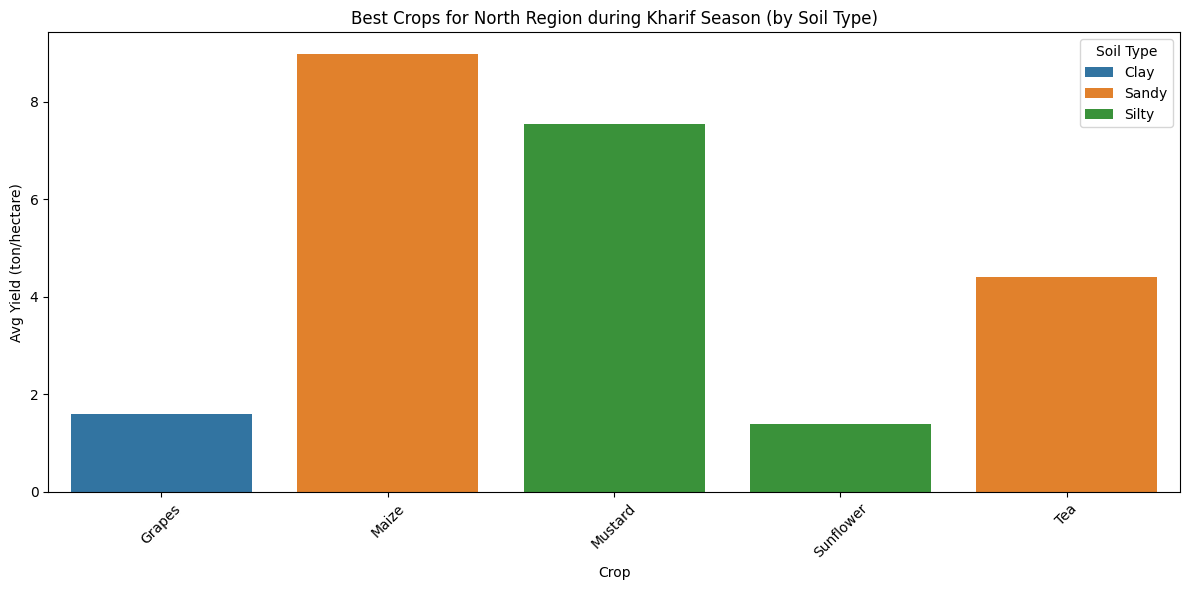

In [81]:
df_filtered = df[(df['Region'] == 'North') & (df['Season'] == 'Kharif')]
grouped = df_filtered.groupby(['Product', 'Soil_Type'])['Avg_Yield_ton_per_hectare'].mean().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(data=grouped, x='Product', y='Avg_Yield_ton_per_hectare', hue='Soil_Type')
plt.title('Best Crops for North Region during Kharif Season (by Soil Type)')
plt.ylabel('Avg Yield (ton/hectare)')
plt.xlabel('Crop')
plt.xticks(rotation=45)
plt.legend(title='Soil Type')
plt.tight_layout()
plt.show()


**(Obseravtion)**

The tallest bar corresponds to a crop (Maize) on Sandy soil with yield ≈ 9 tons/hectare.

This is likely the best performing crop-soil combination in North during Kharif season.

---



(BASED ON CLIMATE)

Here, Climate Features in our Dataset:

Avg_Rainfall_mm

Temperature_C

(You can also consider PH_Soil if relevant to root health)



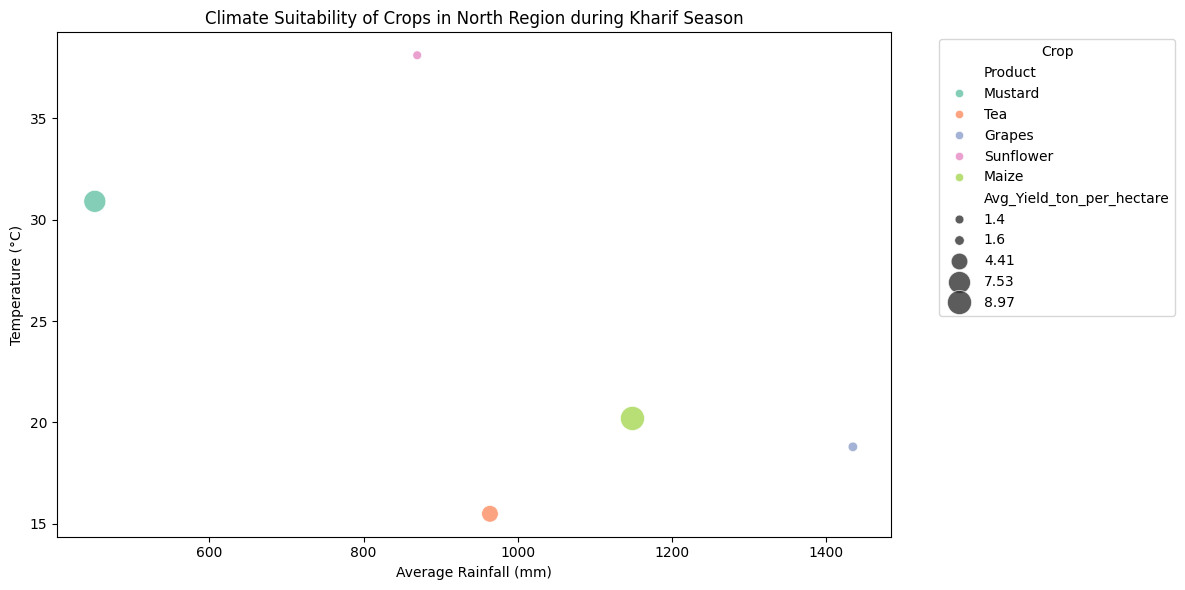

In [82]:
df_filtered = df[(df['Region'] == 'North') & (df['Season'] == 'Kharif')]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df_filtered,
    x='Avg_Rainfall_mm',
    y='Temperature_C',
    hue='Product',
    size='Avg_Yield_ton_per_hectare',
    sizes=(40, 300),
    palette='Set2',
    alpha=0.8
)

plt.title('Climate Suitability of Crops in North Region during Kharif Season')
plt.xlabel('Average Rainfall (mm)')
plt.ylabel('Temperature (°C)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Crop')
plt.tight_layout()
plt.show()


**(Obseravtion)**

Here, Maize is the best performer due to


*   Large Yield

*   It Grows well in moderately hot climates (28–30°C)

---





(BASED ON IRRIGATION TYPE)

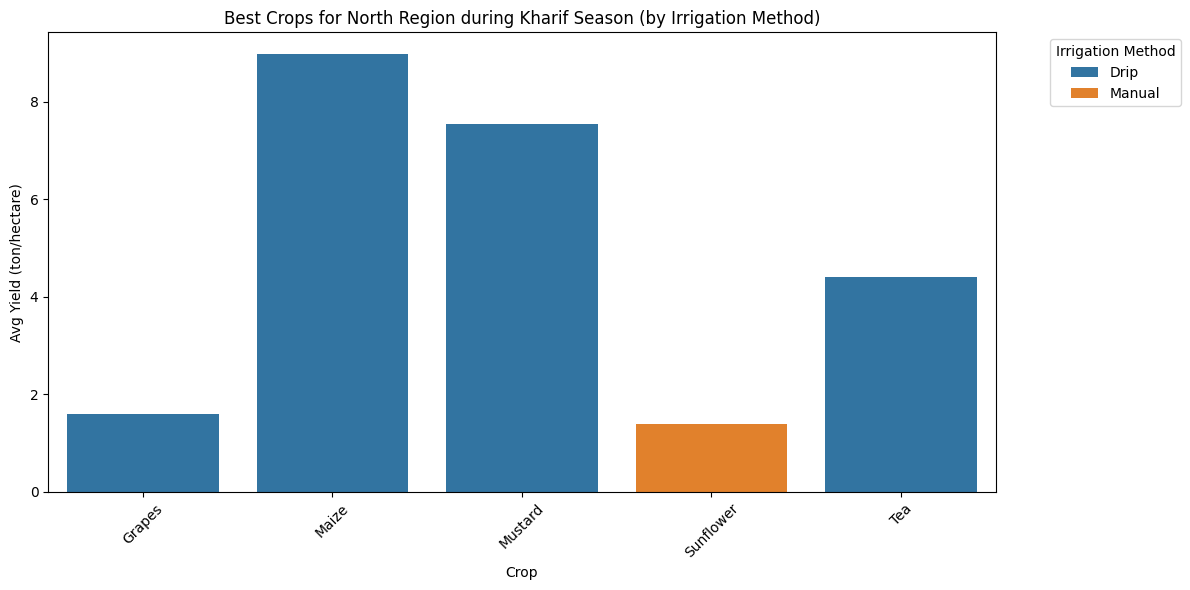

In [83]:
df_filtered = df[(df['Region'] == 'North') & (df['Season'] == 'Kharif')]
grouped = df_filtered.groupby(['Product', 'Irrigation_Method'])['Avg_Yield_ton_per_hectare'].mean().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(data=grouped, x='Product', y='Avg_Yield_ton_per_hectare', hue='Irrigation_Method')
plt.title('Best Crops for North Region during Kharif Season (by Irrigation Method)')
plt.ylabel('Avg Yield (ton/hectare)')
plt.xlabel('Crop')
plt.xticks(rotation=45)
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


**(Observation)**

Maize and Mustard both give excellent yields, suitable if drip systems are available.



---


**[SOUTH / RABI]**

(BASED ON SOIL)

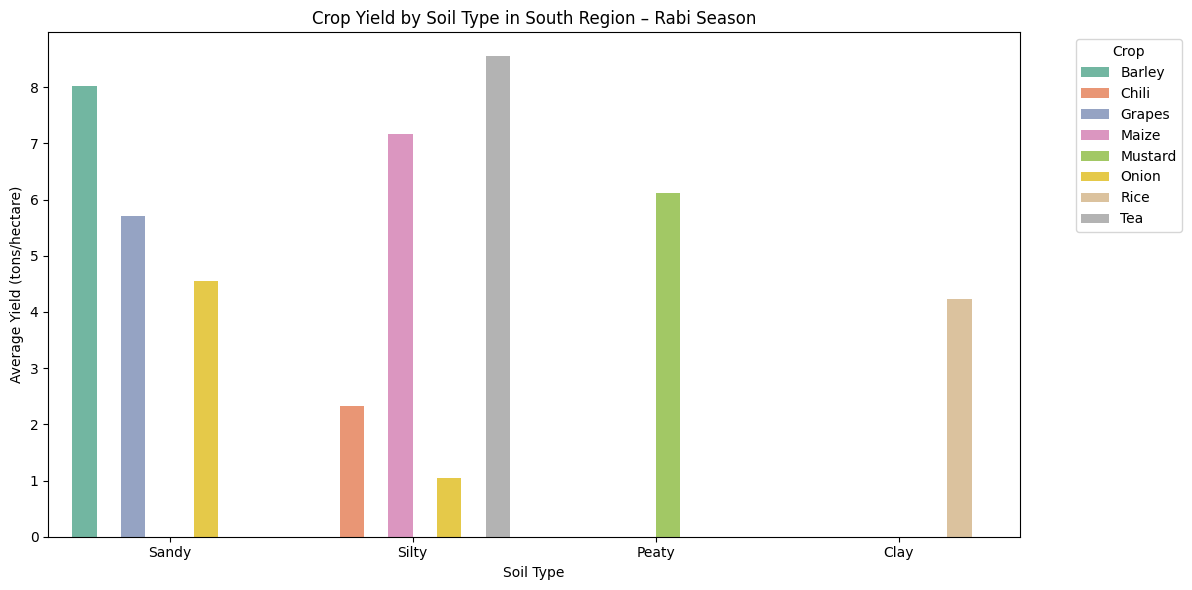

In [84]:
df_filtered = df[(df['Region'] == 'South') & (df['Season'] == 'Rabi')].copy()
soil_yield = df_filtered.groupby(['Product', 'Soil_Type'])['Avg_Yield_ton_per_hectare'].mean().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(
    data=soil_yield,
    x='Soil_Type',
    y='Avg_Yield_ton_per_hectare',
    hue='Product',
    palette='Set2'
)
plt.title('Crop Yield by Soil Type in South Region – Rabi Season')
plt.xlabel('Soil Type')
plt.ylabel('Average Yield (tons/hectare)')
plt.legend(title='Crop', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




---


**(Observation)**

Sandy Soil supports the highest number of crops with good yields:

*   Grapes (~ 8 tons/hectare) and Tea (~ 6 tons/hectare) perform exceptionally well.
*   Onion also gives a moderate yield (~4.5 tons/hectare).

Silty Soil shows moderate to poor performance:

*   Maize gives a good yield (~7.5), but other crops like Rice and Chili perform poorly (under 3 tons/hectare).

Peaty Soil shows specialized suitability:

*   Mustard performs well (~6.5 tons/hectare), but other crops are either absent or underperforming.

Clay Soil

*  It supports Maize moderately (~5 tons/hectare), but no high-yield crops appear here.

---



---













(BASED ON CLIMATE)

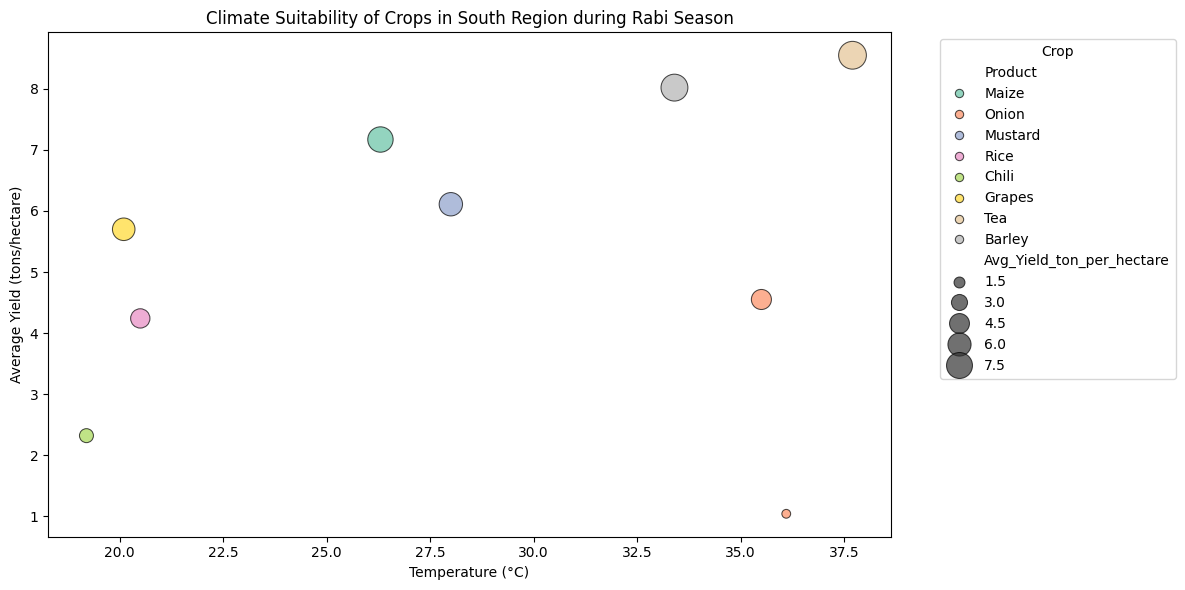

In [85]:
df_filtered = df[(df['Region'] == 'South') & (df['Season'] == 'Rabi')].copy()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df_filtered,
    x='Temperature_C',
    y='Avg_Yield_ton_per_hectare',
    size='Avg_Yield_ton_per_hectare',
    hue='Product',
    sizes=(40, 400),
    palette='Set2',
    alpha=0.7,
    edgecolor='black'
)

plt.title('Climate Suitability of Crops in South Region during Rabi Season')
plt.xlabel('Temperature (°C)')
plt.ylabel('Average Yield (tons/hectare)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Crop')
plt.tight_layout()
plt.show()


**(Observation)**

Maize

*   Temperature: ~25-28°C
*   Yield: ~7.5 tons/hectare

Onion

*   Temperature: ~35 - 37.5°C
*   Yield: ~4.5–5 tons/hectare

Mustard

*   Temperature: ~27.5 - 30°C
*   Yield: ~6 tons/hectare

Rice

*   Temperature: ~20 - 22.5°C
*   Yield: ~4 - 5 tons/hectare

Chili

*   Temperature: ~18 - 20°C
*   Yield: ~2 - 3 tons/hectare

Grapes

*   Temperature: ~20°C
*   Yield: ~5 - 6 ton/hectare

Tea

*   Temperature: ~37.5°C
*   Yield: ~8+ tons/hectare





---



---


**(CONCLUSION)**



*   Tea, Maize, and Mustard are the most climate-suitable crops for the South Region during Rabi Season, based on temperature range and yield.
*   Crops like Chili and Rice may not be ideal unless supported by better soil or irrigation systems.


















(BASED ON IRRIGATION TYPE)

/tmp/ipython-input-86-2457629570.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


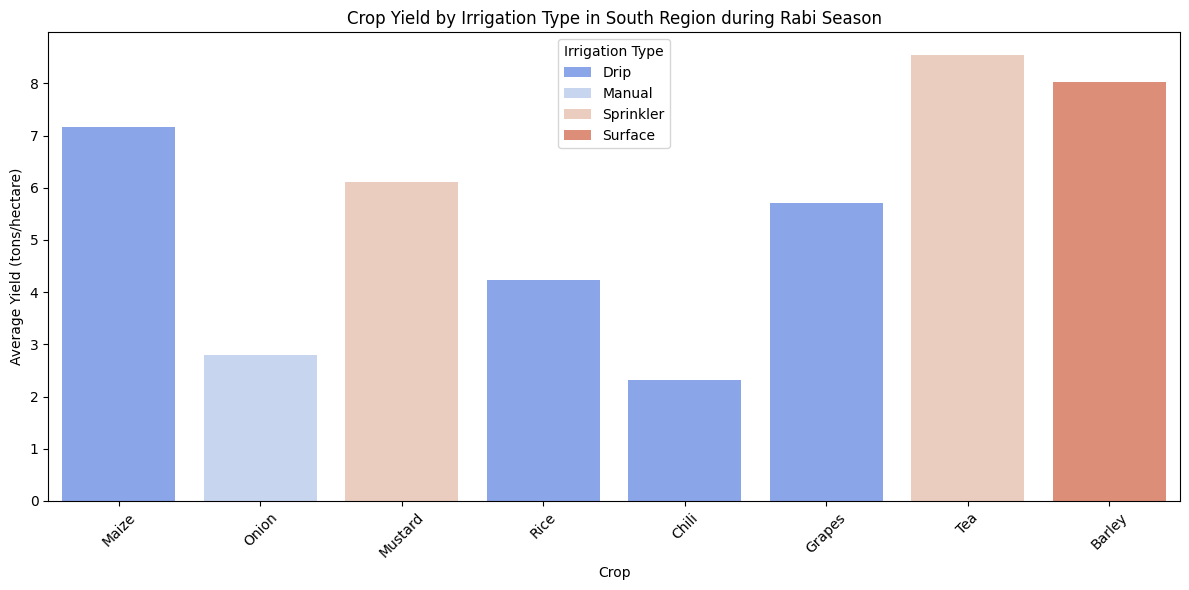

In [86]:
df_filtered = df[(df['Region'] == 'South') & (df['Season'] == 'Rabi')].copy()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_filtered,
    x='Product',
    y='Avg_Yield_ton_per_hectare',
    hue='Irrigation_Method',
    palette='coolwarm',
    ci=None
)
plt.title('Crop Yield by Irrigation Type in South Region during Rabi Season')
plt.xlabel('Crop')
plt.ylabel('Average Yield (tons/hectare)')
plt.xticks(rotation=45)
plt.legend(title='Irrigation Type')
plt.tight_layout()
plt.show()


**(Observation)**



*   Surface irrigation leads to excellent yields for Tea and Barley.


*   Drip irrigation is efficient for Maize and Grapes, but not enough for Chili or Rice.

*   Sprinkler irrigation benefits Mustard the most.
*   Manual irrigation results in poor performance, especially for Onion.





(OVERALL SUMMARY TABLE AND CONCLUSION , METHODOLOGY(HOW I CAME TO GET THIS TABLE))



---



---



**Problem Statement 2:**  -  Which crops should be prioritized for government subsidy based on yield, market price, and export potential

analyzing and ranking crops for government subsidy priority based on:


*   Average Yield (tons/hectare)

*   Market Price (Rs/kg)

*   Export Potential





In [87]:
df['Avg_Yield_ton_per_hectare'] = pd.to_numeric(df['Avg_Yield_ton_per_hectare'], errors='coerce')
df['Market_Price_Rs_per_kg'] = pd.to_numeric(df['Market_Price_Rs_per_kg'], errors='coerce')
df['Export_Potential'] = pd.to_numeric(df['Export_Potential'], errors='coerce')

df_grouped = df.groupby('Product')[['Avg_Yield_ton_per_hectare', 'Market_Price_Rs_per_kg', 'Export_Potential']].mean().reset_index()
df_grouped['Yield_Score'] = (
    (df_grouped['Avg_Yield_ton_per_hectare'] - df_grouped['Avg_Yield_ton_per_hectare'].min()) /
    (df_grouped['Avg_Yield_ton_per_hectare'].max() - df_grouped['Avg_Yield_ton_per_hectare'].min())
)

df_grouped['Price_Score'] = (
    (df_grouped['Market_Price_Rs_per_kg'] - df_grouped['Market_Price_Rs_per_kg'].min()) /
    (df_grouped['Market_Price_Rs_per_kg'].max() - df_grouped['Market_Price_Rs_per_kg'].min())
)
df_grouped['Export_Potential'] = df_grouped['Export_Potential'].fillna(0)


w1, w2, w3 = 0.4, 0.4, 0.2
df_grouped['Final_Score'] = (
    w1 * df_grouped['Yield_Score'] +
    w2 * df_grouped['Price_Score'] +
    w3 * df_grouped['Export_Potential']
)

df_grouped = df_grouped.sort_values(by='Final_Score', ascending=False)
print(df_grouped[['Product', 'Avg_Yield_ton_per_hectare', 'Market_Price_Rs_per_kg', 'Export_Potential', 'Final_Score']])

      Product  Avg_Yield_ton_per_hectare  Market_Price_Rs_per_kg  \
10    Mustard                   6.199091               67.685455   
4      Coffee                   6.375000               55.809000   
13       Rice                   6.735455               50.798182   
15  Sugarcane                   6.852500               43.495000   
12     Potato                   5.629412               55.805882   
1      Banana                   4.384545               60.335455   
18     Tomato                   5.535556               47.261111   
19      Wheat                   5.309000               46.566000   
17        Tea                   4.969231               49.750769   
8       Maize                   4.898750               50.450000   
3       Chili                   5.702222               40.211111   
16  Sunflower                   5.186000               45.264667   
11      Onion                   3.987500               58.300833   
7   Groundnut                   5.680909        

/tmp/ipython-input-88-802824113.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


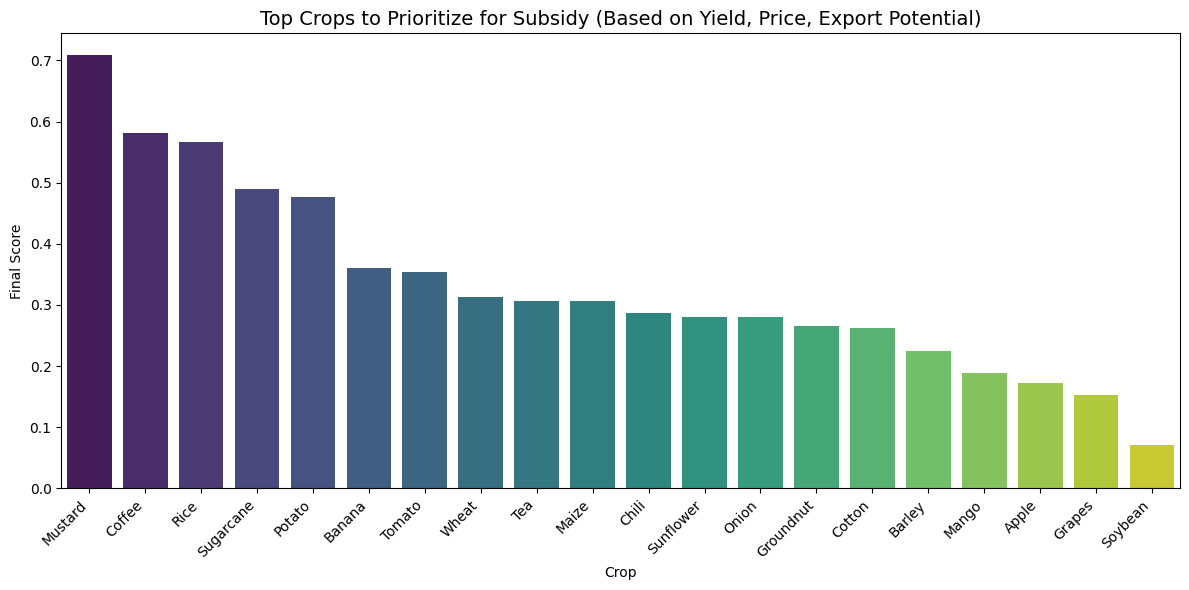

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_grouped,
    x='Product',
    y='Final_Score',
    palette='viridis'
)

# Add labels and title
plt.xticks(rotation=45, ha='right')
plt.title('Top Crops to Prioritize for Subsidy (Based on Yield, Price, Export Potential)', fontsize=14)
plt.xlabel('Crop')
plt.ylabel('Final Score')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/Top_cropp.png')
plt.show()


**(OBSERAVTION):-**

The bar chart shows the ranking of crops based on the combined score (average yield, market price, export potential).

Top Recommended Crops for Government Subsidy:


*  **Mustard**
*   **Coffee, Rice, and Sugarcane also perform strongly**

These crops should be prioritized for subsidy as they show a high balance of productivity and economic value.

